- módulo 1: scraper de película individual
- módulo 2: script por línea de comandos
- módulo 3: lógica de perfil de usuario por géneros
- módulo 4: scraper de cartelera Madrid
- módulo 5: unión cartelera + datos de película
- módulo 6: envío automático por Telegram o email
- módulo 7: Alexa Skill
- módulo 8: interfaz web

Es decir nos basaremos en la siguiente estructura:
peliculas_agent/
│
├─ notebook_pruebas.ipynb
├─ movie_scraper.py
├─ movie_service.py
├─ cache/
│  └─ movies_cache.json
├─ alexa_lambda.py
├─ madrid_showtimes.py
├─ user_profile.json
└─ requirements.txt

1) percepcion: dado el título de una película, obtener sus datos y devolverlos en un diccionario. -> sacar bien los datos

DATOS A EXTRAER:
- titulo
- géneros
- año
- nota
- número de votos
- sinopsis
- director
- duración
- url fuente 

Probaremos con request y Beautifulsoup y si da problemas con Playwright. Si IMDb (la página de donde sacaremos los datos de las películas) necesita navegador real plantearemos el scrapper con Playwright. Detectamos un proble ade que la página puede bloquear accesos automatizados simples.

El primer paso es inspeccionar una pelicula concreta de IMBD y ver donde estan los campos concretos que queremos.

In [ ]:
# intentamos hacer una prueba a ver si nos deja acceder directamente con request
import requests
from bs4 import BeautifulSoup

url = "https://www.imdb.com/es-es/title/tt0816692/?ref_=nv_sr_srsg_0_tt_6_nm_2_in_0_q_INTER"

headers = {
    "User-Agent": "Mozilla/5.0"
}

resp = requests.get(url, headers=headers, timeout=15)

print("STATUS:", resp.status_code)
print(resp.text[:2000])  # imprime solo el inicio del HTML

with open("imdb_interstellar.html", "w", encoding="utf-8") as f:
    f.write(resp.text)

soup = BeautifulSoup(resp.text, "html.parser")
print("TITLE HTML:", soup.title.string if soup.title else "Sin title")

STATUS: 202

TITLE HTML: Sin title


Se intentó inicialmente una solución ligera basada en requests y BeautifulSoup, pero IMDb no devolvía el HTML completo de la ficha de la película, sino una respuesta sin el contenido esperado y que nos indica que nos están vetando por parecer un robot y no nos dejan acceder. Por ello, se optó por una herramienta de automatización de navegador como Playwright, capaz de cargar la página renderizada y acceder al DOM final.

Esta parte la llevaremos a cabo e un .py ya que hay un problema con el entorno de Windows/jupyter y Playwright al intentar lanzar el navegador dentro del notebook por lo que es necesario hacerlo en otro archivo que llamaremos scrapper.py en el cual probaremos si consigue primero entrar en la página correctamente y después abrir con Playwright, guardar el DOM en HTML y, a partir de ahí, sacar los datos.

Hacemos dos archivos nuevos:


debug_save_html.py:


- comprobar que Playwright entra a la página que queremos
- guardar el DOM renderizado en HTML, es decir abre un navegador real, ejecuta JavaScript, construye el DOM y devuelve el DOM convertido a HTML. El DOM no puede obtenerse directamente mediante peticiones HTTP, ya que es una estructura generada por el navegador tras ejecutar JavaScript. Por ello, se utiliza Playwright para simular un navegador real, obtener el DOM renderizado y convertirlo en HTML para su posterior análisis.

- inspeccionar manualmente el DOM y pasarle el archivo que nos genera a LLM para conocer de donde sacar los datos ya que todas la peliculas tienen mas o menos la misma estructura

imdb_scraper_base.py:

En el HTML que se obtiene con debug_save_html se observa que los datos estan contenidos en el bloque application/ld+json de tipo Movie. Aunque se puede utilizar un LLM para extraer la información del DOM, en este proyecto se ha optado por parsear directamente los datos estructurados presentes en el bloque application/ld+json. Este bloque se parsea directamente como JSON, lo que permite extraer información de forma robusta sin depender de la estructura visual del HTML.

- sacar ya los datos estructurados (en el diccionario) solamente pasando la url basandonos en la estructura observada anteriormente


In [ ]:
#se puede observar que se encuentran todos los campos: 
#este seria un ejemplo de lo que encontramos dentro del campo de application/ld+json en el DOM renderizado a HTML de una pagina de IMDB en la primera linea
<script type="application/ld+json">{"@context":"https://schema.org","@type":"Movie","url":"https://www.imdb.com/es-es/title/tt0062622/","name":"2001: A Space Odyssey","alternateName":"2001: Una odisea del espacio","image":"https://m.media-amazon.com/images/M/MV5BYTY2YzQyNTctOTM4MS00OGNjLWIwOTgtZjNjMTViNzIxMzZkXkEyXkFqcGc@._V1_.jpg","description":"Tras su descubrimiento en África hace varias generaciones, los misteriosos monolitos conducen a la humanidad a un impresionante viaje a Júpiter, con la ayuda del superordenador HAL 9000.","review":{"@type":"Review","itemReviewed":{"@type":"Movie","url":"https://www.imdb.com/es-es/title/tt0062622/"},"author":{"@type":"Person","name":"briancham1994"},"dateCreated":"2020-08-10","inLanguage":"English","name":"I don&apos;t get it","reviewBody":"Count me as one of the philistines who is too simple-minded to appreciate this so-called masterpiece. Actually, I have a degree in media studies and a great interest in science, science fiction and anything thought-provoking (the technical term is &quot;need for cognition&quot;). But I am just baffled by this film and why it is so esteemed. It is simply slow, empty and lifeless. When absolutely nothing is happening on screen, am I supposed to feel or think something profound? Even when my professor explicitly explained to me why this film is so great, I still cannot convince myself that it is so.","reviewRating":{"@type":"Rating","worstRating":1,"bestRating":10,"ratingValue":6}},"aggregateRating":{"@type":"AggregateRating","ratingCount":782094,"bestRating":10,"worstRating":1,"ratingValue":8.3},"contentRating":"A","genre":["Aventura","Ciencia ficción"],"datePublished":"1968-10-17","keywords":"monolith,human versus computer,ordenador,inteligencia artificial,star child","trailer":{"@type":"VideoObject","name":"New 70mm Trailer","embedUrl":"https://www.imdb.com/es-es/video/vi2674767897/","thumbnail":{"@type":"ImageObject","contentUrl":"https://m.media-amazon.com/images/M/MV5BZGJiOGEyYWQtNWYyMC00MWRiLWIzMzMtNTMxNjVlMGEwZWM3XkEyXkFqcGdeQXRodW1ibmFpbC1pbml0aWFsaXplcg@@._V1_.jpg"},"thumbnailUrl":"https://m.media-amazon.com/images/M/MV5BZGJiOGEyYWQtNWYyMC00MWRiLWIzMzMtNTMxNjVlMGEwZWM3XkEyXkFqcGdeQXRodW1ibmFpbC1pbml0aWFsaXplcg@@._V1_.jpg","url":"https://www.imdb.com/es-es/video/vi2674767897/","description":"Humanity finds a mysterious, obviously artificial object buried beneath the Lunar surface and, with the intelligent computer H.A.L. 9000, sets off on a quest.","duration":"PT2M24S","uploadDate":"2018-04-20T21:39:40Z"},"actor":[{"@type":"Person","url":"https://www.imdb.com/es-es/name/nm0001158/","name":"Keir Dullea"},{"@type":"Person","url":"https://www.imdb.com/es-es/name/nm0516972/","name":"Gary Lockwood"},{"@type":"Person","url":"https://www.imdb.com/es-es/name/nm0843213/","name":"William Sylvester"}],"director":[{"@type":"Person","url":"https://www.imdb.com/es-es/name/nm0000040/","name":"Stanley Kubrick"}],"creator":[{"@type":"Organization","url":"https://www.imdb.com/es-es/company/co0007143/"},{"@type":"Organization","url":"https://www.imdb.com/es-es/company/co0038089/"},{"@type":"Person","url":"https://www.imdb.com/es-es/name/nm0000040/","name":"Stanley Kubrick"},{"@type":"Person","url":"https://www.imdb.com/es-es/name/nm0002009/","name":"Arthur C. Clarke"}],"duration":"PT2H29M"}</script><meta property="og:url" content="https://www.imdb.com/es-es/title/tt0062622/"><meta property="og:site_name" content="IMDb"><meta property="og:title" content="2001: Una odisea del espacio (1968) ⭐ 8.3 | Aventura, Ciencia ficción"><meta property="og:description" content="2h 29m | A"><meta property="og:type" content="video.movie"><meta property="og:image" content="https://m.media-amazon.com/images/M/MV5BYTY2YzQyNTctOTM4MS00OGNjLWIwOTgtZjNjMTViNzIxMzZkXkEyXkFqcGc@._V1_FMjpg_UX1000_.jpg"><meta property="og:image:height" content="1500"><meta property="og:image:width" content="1000"><meta content="es_ES" property="og:locale"><meta content="en_US" property="og:locale:alternate"><meta content="es_MX" property="og:locale:alternate"><meta content="fr_FR" property="og:locale:alternate"><meta content="fr_CA" property="og:locale:alternate"><meta content="it_IT" property="og:locale:alternate"><meta content="pt_BR" property="og:locale:alternate"><meta content="hi_IN" property="og:locale:alternate"><meta content="de_DE" property="og:locale:alternate"><meta property="twitter:site" content="@IMDb"><meta property="twitter:title" content="2001: Una odisea del espacio (1968) ⭐ 8.3 | Aventura, Ciencia ficción"><meta property="twitter:description" content="2h 29m | A"><meta property="twitter:card" content="summary_large_image"><meta property="twitter:image" content="https://m.media-amazon.com/images/M/MV5BYTY2YzQyNTctOTM4MS00OGNjLWIwOTgtZjNjMTViNzIxMzZkXkEyXkFqcGc@._V1_FMjpg_UX1000_.jpg"><meta property="twitter:image:alt" content="2001: Una odisea del espacio: Dirigido por Stanley Kubrick. Con Keir Dullea, Gary Lockwood, William Sylvester, Daniel Richter. Tras su descubrimiento en África hace varias generaciones, los misteriosos monolitos conducen a la humanidad a un impresionante viaje a Júpiter, con la ayuda del superordenador HAL 9000."><link rel="canonical" href="https://www.imdb.com/es-es/title/tt0062622/"><link rel="alternate" href="https://www.imdb.com/title/tt0062622/" hreflang="x-default"><link rel="alternate" href="https://www.imdb.com/title/tt0062622/" hreflang="en"><link rel="alternate" href="https://www.imdb.com/de/title/tt0062622/" hreflang="de"><link rel="alternate" href="https://www.imdb.com/es/title/tt0062622/" hreflang="es"><link rel="alternate" href="https://www.imdb.com/es-es/title/tt0062622/" hreflang="es-es"><link rel="alternate" href="https://www.imdb.com/fr/title/tt0062622/" hreflang="fr"><link rel="alternate" href="https://www.imdb.com/fr-ca/title/tt0062622/" hreflang="fr-ca"><link rel="alternate" href="https://www.imdb.com/hi/title/tt0062622/" hreflang="hi"><link rel="alternate" href="https://www.imdb.com/it/title/tt0062622/" hreflang="it"><link rel="alternate" href="https://www.imdb.com/pt/title/tt0062622/" hreflang="pt"><meta property="imdb:pageType" content="title"><meta property="imdb:subPageType" content="main"><meta property="imdb:pageConst" content="tt0062622"><script>if(typeof uet === 'function'){ uet('be', 'LoadTitle', {wb: 1}); }</script><script>if(typeof uex === 'function'){ uex('ld', 'LoadTitle', {wb: 1}); }</script><script>window.addEventListener('load', (event) => 

Hasta ahora para conseguir toda esta estructura hemos usado urls de IMDB pero ahora lo que buscamos es pasar el título de la película por consola y que nos devuelva todos los campos por ello vamos a usar como archivo final para eso movie_scrapper.py

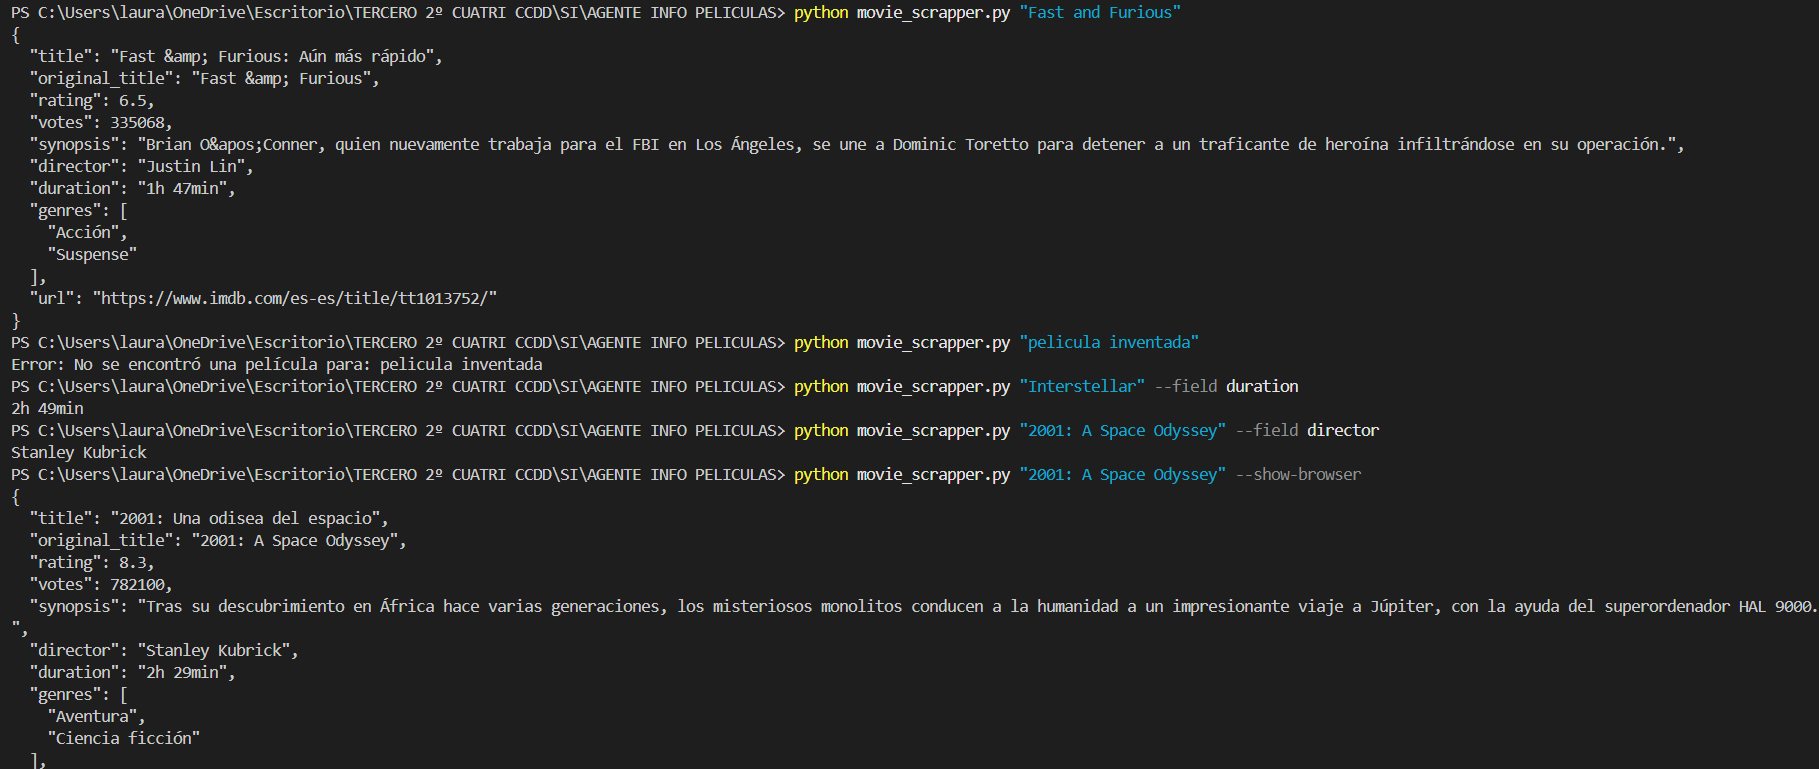

Aqui se puede observar el resultado y que nos devuelve correctamente los datos con los campos que queremos, añadimos como atributos para pasarle por consola --field para añadir concretamente el dato que queremos, --show-browser que nos muestra el proceso de búsqueda en el navegador y que nos enseña la página donde busca los datos y tambien se puede pasar el nombre de la pelicula solamente y ahí nos da todos los datos completos.

## 2) SKILL DE ALEXA
 Un skill de Alexa que utilizará el scrapper anterior para, cuando el usuario le  pida algún dato de una película (por ejemplo: ¿cuál es la nota de 2001?), le conteste con el dato.

El skill será como una capa por encima de nuestro scrapper anterior. Alexa escucha -> detecta intent + pelicula -> llama a nuestra funcion -> devuelve texto para hablar 

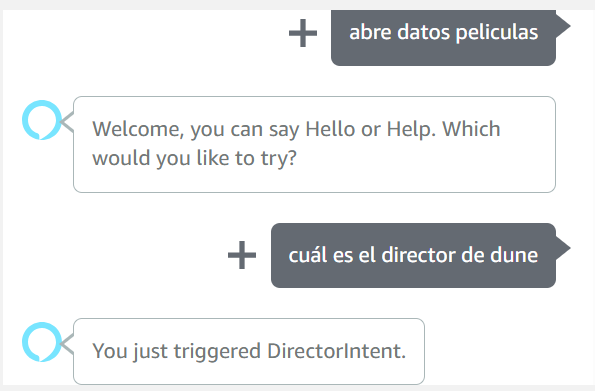

Al modificar lambda_function.py de la parte de code del skill y hacer la prueba comprobamos que ya esta usando nuestro codigo y lo que tenemos que hacer es conectarlo a nuestro scrapper 

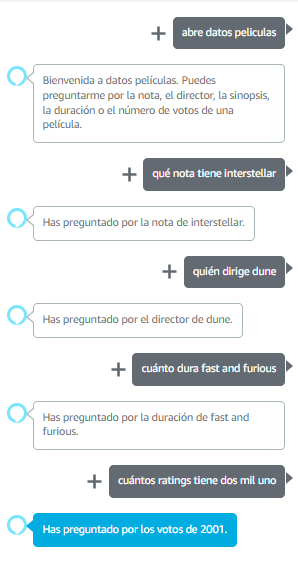

Ahora necesitamos llamar al scrapper real. 
Como nuestro scrapper utiliza plywright y esto da problemas y tampoco puede lanzar un navegador Chronium para incluirlo dentro de la lambda de Alexa lo que vamos a hacer es:
- Alexa = frontend de voz
- scraper = servicio aparte
- Alexa le pregunta al scraper y recibe JSON

Además también debemos de añadir el caché para que si se vuelve a preguntar por la misma película no lance otra vez la consulta al IMDb. Esto lo haremos fuera de Alexa.

Vamos a implementar:


Usuario habla a Alexa


       ↓


Lambda de AWS


       ↓  hace una petición HTTP


Tu API (Flask corriendo con grok en el ordenador)


       ↓


Tu scrapper con Playwright (aquí sí puede abrir Chrome)


       ↓

       
Devuelve los datos a Lambda → Alexa los lee

es decir implementamos esta arquitectura:
Alexa → Lambda (AWS) → ngrok URL → Flask API (PC) → Playwright scrapper → IMDb

Para llegar a tener la API vamos a usar ngrok https://ngrok.com/signup para que nos de una URL y Alexa pueda hacer las peticiones HTTP desde nuestro lambda. Para hacerlo más limpio vamos a hacerlo desde docker la configuración e instalacion de ngrok

detectamos un problema: nuestro scrapper hace esto en cada consulta nueva:

1. Abrir Playwright     → ~2-3 segundos
2. Lanzar Chromium      → ~2-3 segundos  
3. Navegar a IMDb       → ~3-5 segundos
4. wait_for_timeout(3000) en búsqueda  → 3 segundos fijos
5. wait_for_timeout(5000) en película  → 5 segundos fijos
Total mínimo: ~15-20 segundos

Alexa/Lambda tiene un timeout de 8 segundos. Con 15-20 segundos siempre falla en frío. Por lo que tenemos que optimizar el scrapper y hacer el Browser persistente en Flask modificando api.py

Optimizando el scrapper solo ahorramos los 8 segundos fijos pero el problema de fondo sigue siendo que Playwright abre y cierra Chronium en cada petición. Por ello, en vez de abrir y cerrrar Chronium en cada request, lo mantenemos abierto mientras Flask está corriendo y eso elimina el coste de arranque en cada petición.

<script type="application/ld+json">{"@context":"https://schema.org","@type":"Movie","url":"https://www.imdb.com/es-es/title/tt0062622/","name":"2001: A Space Odyssey","alternateName":"2001: Una odisea del espacio","image":"https://m.media-amazon.com/images/M/MV5BYTY2YzQyNTctOTM4MS00OGNjLWIwOTgtZjNjMTViNzIxMzZkXkEyXkFqcGc@._V1_.jpg","description":"Tras su descubrimiento en África hace varias generaciones, los misteriosos monolitos conducen a la humanidad a un impresionante viaje a Júpiter, con la ayuda del superordenador HAL 9000.","review":{"@type":"Review","itemReviewed":{"@type":"Movie","url":"https://www.imdb.com/es-es/title/tt0062622/"},"author":{"@type":"Person","name":"briancham1994"},"dateCreated":"2020-08-10","inLanguage":"English","name":"I don&apos;t get it","reviewBody":"Count me as one of the philistines who is too simple-minded to appreciate this so-called masterpiece. Actually, I have a degree in media studies and a great interest in science, science fiction and anything thought-provoking (the technical term is &quot;need for cognition&quot;). But I am just baffled by this film and why it is so esteemed. It is simply slow, empty and lifeless. When absolutely nothing is happening on screen, am I supposed to feel or think something profound? Even when my professor explicitly explained to me why this film is so great, I still cannot convince myself that it is so.","reviewRating":{"@type":"Rating","worstRating":1,"bestRating":10,"ratingValue":6}},"aggregateRating":{"@type":"AggregateRating","ratingCount":782094,"bestRating":10,"worstRating":1,"ratingValue":8.3},"contentRating":"A","genre":["Aventura","Ciencia ficción"],"datePublished":"1968-10-17","keywords":"monolith,human versus computer,ordenador,inteligencia artificial,star child"}

BOT DE TELEGRAM QUE SE CONECTA A LA API

ag_peli_bot

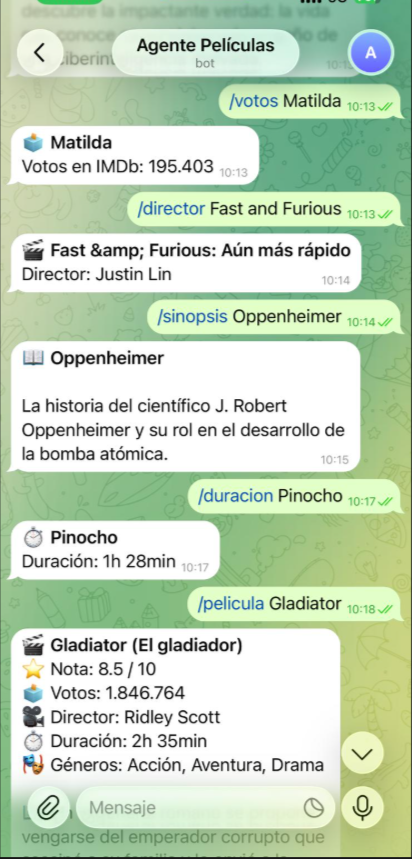
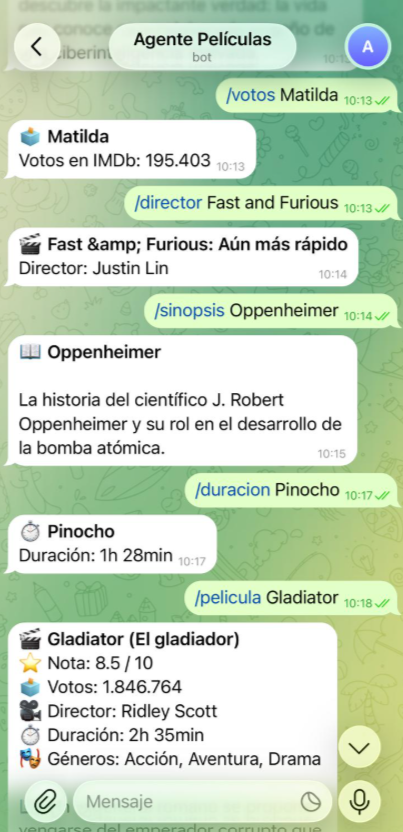

DESPUÉS TENEMOS QUE HACER: 

"Otro scrapper que obtenga la cartelera de cine de Madrid (por ejemplo de https://www.ecartelera.com) e integre esta información con la proporcionada por el scrapper anterior. Este scrapper se ejecutará todos los lunes a las 9:00 (usar cron) y enviará el resultado por telegram o por mail."

Y OPCIONALEMENTE:

"Utilizar un perfil del usuario que valore cada género, filtre la nota por ese perfil. Por ejemplo 'Ciencia ficción: 6' dejaría pasar el filtro a las películas que siendo de ciencia ficción tengan más de un 6. Se pueden incluir directores favoritos, etc." (El perfil de usuario es simplemente un diccionario configurable donde defines tus preferencias,)

Es decir, 
1) Scrapper que saque las películas en cartelera en Madrid de ecartelera.com
2) Para cada película de la cartelera, obtener su nota de IMDb usando tu scrapper ya hecho
3) Filtrar por nota mínima (por ejemplo solo las que tengan más de 6)
4) Enviar el resultado por Telegram
5) Que esto se ejecute automáticamente todos los lunes a las 9:00 con cron